In [1]:
#!pip install transformers datasets sentencepiece sacremoses 

In [2]:
#!pip install transformers[torch]

In [3]:
from datasets import load_dataset
import accelerate

In [4]:
data = load_dataset("kde4", lang1="en", lang2="fr", trust_remote_code=True)
data

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 210173
    })
})

In [5]:
!pip install transformers[torch]

In [6]:
#select 100 small samples
small = data['train'].shuffle(seed=42).select(range(5000))
small

Dataset({
    features: ['id', 'translation'],
    num_rows: 5000
})

In [7]:
#train test split
split = small.train_test_split(seed=42, test_size=0.1)
split

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 4500
    })
    test: Dataset({
        features: ['id', 'translation'],
        num_rows: 500
    })
})

In [8]:
split['train'][100]

{'id': '50148',
 'translation': {'en': 'The & CUPS; Module in & kdeprint; now contains all (and more) functions that were provided by qtcups and kups in former & kde; versions.',
  'fr': 'Le module & CUPS; dans & kdeprint; contient maintenant toutes les fonctions (et plus) qui étaient fournies par qtcups et kups dans les versions précédentes de & kde;.'}}

In [9]:
split['train'][600]

{'id': '75769',
 'translation': {'en': 'Enter a search value. An ISBN search must include the full ISBN.',
  'fr': 'Saisissez une valeur à chercher. Une recherche ISBN doit inclure le numéro ISBN complet.'}}

In [10]:
from transformers import AutoTokenizer

In [11]:
ckpt = "Helsinki-NLP/opus-mt-en-fr"
tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [12]:
## inp = tokenizer(en_sentence) #tokenizes english sentence
## targets = tokenizer(text_target=es_sentence) --> tokenizes french sentence

In [13]:
en = split['train'][5]['translation']['en']
fr = split['train'][5]['translation']['fr']
en, fr

('David Faure', 'David Faure')

In [14]:
inputs = tokenizer(en)
print(en)
print(inputs)

David Faure
{'input_ids': [3206, 28400, 158, 0], 'attention_mask': [1, 1, 1, 1]}


In [15]:
targets = tokenizer(text_target=fr)
print(fr)
print(targets)

David Faure
{'input_ids': [3206, 6344, 1935, 0], 'attention_mask': [1, 1, 1, 1]}


In [16]:
tokenizer.convert_ids_to_tokens(targets['input_ids'])

['▁David', '▁Fa', 'ure', '</s>']

In [17]:
import matplotlib.pyplot as plt
train = split['train']['translation']
input_lens = [len(tr['en']) for tr in train]

In [18]:
train

[{'en': 'KCall', 'fr': 'KCallName'},
 {'en': '... that you do not need to bother with any settings if you do not know what they mean. K3b is able to choose the settings best suited for you.',
  'fr': "... que vous n'avez pas besoin de vous tracasser avec des options dont vous ne comprenez pas le sens. K3b est en mesure de choisir les paramètres les plus adaptés pour vous."},
 {'en': 'Maximize file system on %1 to fill the partition',
  'fr': 'Maximiser le système de fichiers sur %1 pour remplir la partition@info/ plain'},
 {'en': 'Debug Launch',
  'fr': "Débogage de lancementShort text for 'Debug Launch 'used in the toolbar"},
 {'en': 'There was an error creating your report: "%1". Please report this error to the developer\'s list: kmymoney-devel@kde. org',
  'fr': 'Il a eu une erreur critique pendant la création de votre rapport: "%1". S\'il vous plaît, veuillez rapporter cette erreur aux développeurs à l\'adresse suivante: kmymoney2-developer@lists. sourceforge. net'},
 {'en': 'David

In [19]:
input_lens

[5,
 143,
 48,
 12,
 120,
 11,
 51,
 25,
 34,
 14,
 26,
 23,
 10,
 62,
 222,
 12,
 40,
 34,
 37,
 158,
 46,
 22,
 43,
 13,
 14,
 360,
 18,
 54,
 9,
 10,
 21,
 13,
 67,
 70,
 3,
 23,
 15,
 18,
 81,
 2,
 15,
 18,
 27,
 305,
 8,
 232,
 13,
 26,
 11,
 46,
 162,
 49,
 7,
 20,
 5,
 7,
 47,
 18,
 187,
 14,
 212,
 8,
 10,
 9,
 10,
 5,
 3,
 375,
 17,
 11,
 8,
 10,
 19,
 24,
 58,
 19,
 45,
 7,
 17,
 14,
 38,
 66,
 10,
 7,
 6,
 24,
 20,
 14,
 202,
 80,
 8,
 36,
 242,
 11,
 13,
 150,
 14,
 17,
 141,
 5,
 136,
 15,
 4,
 31,
 24,
 49,
 10,
 4,
 34,
 16,
 12,
 3,
 14,
 18,
 122,
 13,
 10,
 31,
 23,
 2,
 22,
 16,
 6,
 5,
 14,
 24,
 15,
 4,
 3,
 614,
 117,
 104,
 32,
 34,
 80,
 8,
 198,
 44,
 19,
 16,
 223,
 10,
 14,
 77,
 324,
 9,
 3,
 16,
 96,
 12,
 50,
 1629,
 403,
 13,
 9,
 34,
 7,
 11,
 34,
 31,
 12,
 33,
 42,
 7,
 9,
 42,
 38,
 7,
 25,
 10,
 45,
 4,
 9,
 18,
 8,
 87,
 7,
 125,
 33,
 11,
 26,
 33,
 43,
 3,
 11,
 6,
 9,
 13,
 10,
 12,
 10,
 16,
 6,
 104,
 47,
 19,
 6,
 11,
 24,
 8,
 11,
 11,
 9,
 1

(array([3.598e+03, 4.230e+02, 1.700e+02, 9.500e+01, 6.100e+01, 4.100e+01,
        3.300e+01, 2.400e+01, 1.300e+01, 1.400e+01, 4.000e+00, 4.000e+00,
        8.000e+00, 3.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([1.00000e+00, 4.87200e+01, 9.64400e+01, 1.44160e+02, 1.91880e+02,
        2.39600e+02, 2.87320e+02, 3.35040e+02, 3.82760e+02, 4.30480e+02,
        4.78200e+02, 5.25920e+02, 5.73640e+02, 6.21360e+02, 6.69080e+02,
        7.16800e+02, 7.64520e+02, 8.12240e+02, 8.59960e+02, 9.07680e+02,
        9.55400e+02, 1.00312e+03, 1.05084e+03, 1.09856e+03, 1.14628e+03,
        1.1

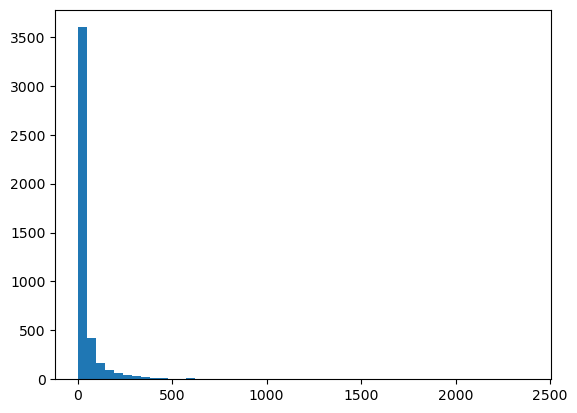

In [20]:
plt.hist(input_lens, bins=50)

In [21]:
target_lens = [len(tr['fr'])for tr in train]
target_lens

[9,
 173,
 77,
 70,
 203,
 11,
 59,
 39,
 62,
 25,
 12,
 29,
 36,
 56,
 244,
 12,
 51,
 58,
 45,
 211,
 79,
 43,
 45,
 18,
 22,
 460,
 18,
 58,
 28,
 17,
 32,
 12,
 98,
 72,
 3,
 52,
 16,
 17,
 94,
 3,
 19,
 40,
 48,
 402,
 20,
 295,
 17,
 29,
 23,
 75,
 248,
 81,
 8,
 24,
 9,
 24,
 55,
 20,
 183,
 36,
 264,
 6,
 38,
 17,
 93,
 12,
 22,
 436,
 21,
 14,
 12,
 18,
 19,
 42,
 62,
 20,
 56,
 7,
 32,
 29,
 43,
 136,
 7,
 8,
 18,
 24,
 30,
 14,
 241,
 64,
 33,
 52,
 336,
 11,
 14,
 215,
 27,
 20,
 155,
 5,
 166,
 30,
 5,
 30,
 30,
 75,
 24,
 41,
 50,
 16,
 27,
 3,
 21,
 29,
 159,
 13,
 19,
 28,
 19,
 23,
 32,
 33,
 6,
 18,
 16,
 19,
 16,
 4,
 36,
 722,
 210,
 142,
 39,
 34,
 128,
 10,
 230,
 44,
 21,
 21,
 245,
 25,
 30,
 103,
 423,
 18,
 3,
 16,
 99,
 25,
 47,
 1901,
 493,
 11,
 9,
 51,
 11,
 49,
 38,
 53,
 12,
 45,
 78,
 7,
 21,
 47,
 63,
 27,
 34,
 20,
 51,
 56,
 7,
 20,
 9,
 106,
 36,
 148,
 44,
 20,
 29,
 25,
 41,
 3,
 17,
 19,
 12,
 26,
 10,
 12,
 51,
 23,
 18,
 108,
 59,
 21,
 6,
 14,

(array([3.667e+03, 4.340e+02, 1.680e+02, 7.700e+01, 5.700e+01, 2.800e+01,
        2.300e+01, 1.700e+01, 9.000e+00, 6.000e+00, 6.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([1.0000e+00, 7.3800e+01, 1.4660e+02, 2.1940e+02, 2.9220e+02,
        3.6500e+02, 4.3780e+02, 5.1060e+02, 5.8340e+02, 6.5620e+02,
        7.2900e+02, 8.0180e+02, 8.7460e+02, 9.4740e+02, 1.0202e+03,
        1.0930e+03, 1.1658e+03, 1.2386e+03, 1.3114e+03, 1.3842e+03,
        1.4570e+03, 1.5298e+03, 1.6026e+03, 1.6754e+03, 1.7482e+03,
        1.8210e+03, 1.8938e+03, 1.96

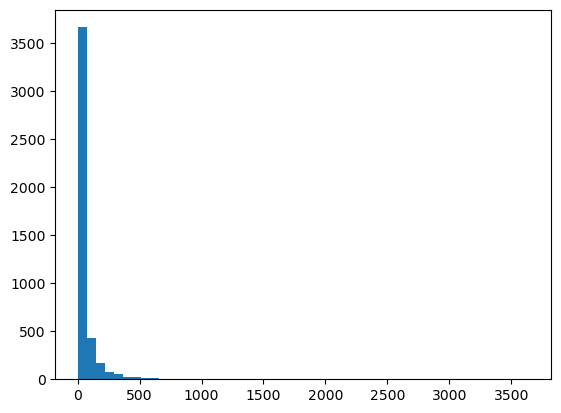

In [22]:
plt.hist(target_lens, bins=50)

In [23]:
tokenizer

MarianTokenizer(name_or_path='Helsinki-NLP/opus-mt-en-fr', vocab_size=59514, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	59513: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [24]:
split

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 4500
    })
    test: Dataset({
        features: ['id', 'translation'],
        num_rows: 500
    })
})

In [25]:
split['train'][100]['translation']

{'en': 'The & CUPS; Module in & kdeprint; now contains all (and more) functions that were provided by qtcups and kups in former & kde; versions.',
 'fr': 'Le module & CUPS; dans & kdeprint; contient maintenant toutes les fonctions (et plus) qui étaient fournies par qtcups et kups dans les versions précédentes de & kde;.'}

In [26]:
max_input_len = 128
max_target_len = 128

def tokenizer_fn(batch):
    inputs = [x['en'] for x in batch['translation']]
    targets = [x['fr'] for x in batch['translation']]

    tokenized_inputs = tokenizer(inputs, max_length=max_input_len, truncation=True)
    tokenized_targets = tokenizer(text_target=targets, max_length=max_target_len, truncation=True)
    tokenized_inputs['labels'] = tokenized_targets['input_ids']

    return tokenized_inputs

In [27]:
tokenized_datasets = split.map(
    tokenizer_fn,
    batched=True,
    remove_columns=split['train'].column_names
)

In [28]:
from transformers import AutoModelForSeq2SeqLM
model = AutoModelForSeq2SeqLM.from_pretrained(ckpt)

In [29]:
from transformers import DataCollatorForSeq2Seq
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [30]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 4500
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 500
    })
})

In [31]:
[tokenized_datasets['train'][i] for i in range(1, 3)]

[{'input_ids': [692,
   33,
   55,
   197,
   73,
   354,
   12,
   21983,
   42,
   212,
   10642,
   235,
   55,
   197,
   73,
   340,
   270,
   154,
   1771,
   3,
   526,
   602,
   226,
   32,
   1154,
   12,
   3826,
   4,
   10642,
   877,
   20854,
   26,
   55,
   3,
   0],
  'attention_mask': [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1],
  'labels': [692,
   29,
   88,
   81,
   6,
   4110,
   53,
   851,
   5,
   88,
   6126,
   33043,
   139,
   72,
   13,
   2118,
   284,
   88,
   76,
   27772,
   53,
   19,
   1388,
   3,
   526,
   602,
   226,
   43,
   23,
   653,
   5,
   4094,
   16,
   7337,
   16,
   65,
   11487,
   27,
   88,
   3,
   0]},
 {'input_ids': [21984, 3317, 1437, 338, 30, 301, 548, 12, 6661, 4, 15388, 0],
  'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  'labels': [21984,
   3353

In [32]:
batch = data_collator([tokenized_datasets['train'][i] for i in range(1, 3)])
batch.keys()

dict_keys(['input_ids', 'attention_mask', 'labels', 'decoder_input_ids'])

In [33]:
batch

{'input_ids': tensor([[  692,    33,    55,   197,    73,   354,    12, 21983,    42,   212,
         10642,   235,    55,   197,    73,   340,   270,   154,  1771,     3,
           526,   602,   226,    32,  1154,    12,  3826,     4, 10642,   877,
         20854,    26,    55,     3,     0],
        [21984,  3317,  1437,   338,    30,   301,   548,    12,  6661,     4,
         15388,     0, 59513, 59513, 59513, 59513, 59513, 59513, 59513, 59513,
         59513, 59513, 59513, 59513, 59513, 59513, 59513, 59513, 59513, 59513,
         59513, 59513, 59513, 59513, 59513]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'labels': tensor([[  692,    29,    88,    81,     6,  4110,    53,   851,     5,    88,
          6126, 33043,   139,    72,    13,  2118,   284,    88

In [34]:
tokenizer.decode(59513)

'<pad>'

In [35]:
tokenizer.decode(526)

'K'

In [36]:
print(batch['input_ids'][1])
print("#####inputs_ids################################################################################")
print(batch['attention_mask'][1])
print("#####attention_mask############################################################################")
print(batch['labels'][1])
print("#####labels####################################################################################")
print(batch['decoder_input_ids'][1])
print("#####decoder_input_ids#########################################################################")

tensor([21984,  3317,  1437,   338,    30,   301,   548,    12,  6661,     4,
        15388,     0, 59513, 59513, 59513, 59513, 59513, 59513, 59513, 59513,
        59513, 59513, 59513, 59513, 59513, 59513, 59513, 59513, 59513, 59513,
        59513, 59513, 59513, 59513, 59513])
#####inputs_ids################################################################################
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
#####attention_mask############################################################################
tensor([21984,  3353,    19,   369,     5,  4027,    36,   301,   548,    27,
         5288,     8, 15388,  1802,  7492,    74, 13252,     0,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100])
#####labels#####################################################################

In [37]:
print(batch['input_ids'].shape)
print("#####inputs_ids################################################################################")
print(batch['attention_mask'].shape)
print("#####attention_mask############################################################################")
print(batch['labels'].shape)
print("#####labels####################################################################################")
print(batch['decoder_input_ids'].shape)
print("#####decoder_input_ids#########################################################################")

torch.Size([2, 35])
#####inputs_ids################################################################################
torch.Size([2, 35])
#####attention_mask############################################################################
torch.Size([2, 41])
#####labels####################################################################################
torch.Size([2, 41])
#####decoder_input_ids#########################################################################


In [38]:
tokenizer.decode(0)

'</s>'

In [39]:
tokenizer

MarianTokenizer(name_or_path='Helsinki-NLP/opus-mt-en-fr', vocab_size=59514, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	59513: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [40]:
tokenizer.convert_ids_to_tokens(batch['labels'][1])

['▁Maxim',
 'iser',
 '▁le',
 '▁système',
 '▁de',
 '▁fichiers',
 '▁sur',
 '▁%',
 '1',
 '▁pour',
 '▁remplir',
 '▁la',
 '▁partition',
 '@',
 'info',
 '/',
 '▁plain',
 '</s>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>',
 '<unk>']

In [41]:
batch['decoder_input_ids'].shape

torch.Size([2, 41])

In [42]:
tokenizer.convert_ids_to_tokens(batch['decoder_input_ids'][1])

['<pad>',
 '▁Maxim',
 'iser',
 '▁le',
 '▁système',
 '▁de',
 '▁fichiers',
 '▁sur',
 '▁%',
 '1',
 '▁pour',
 '▁remplir',
 '▁la',
 '▁partition',
 '@',
 'info',
 '/',
 '▁plain',
 '</s>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>',
 '<pad>']

In [43]:
split['train'][1]

{'id': '64291',
 'translation': {'en': '... that you do not need to bother with any settings if you do not know what they mean. K3b is able to choose the settings best suited for you.',
  'fr': "... que vous n'avez pas besoin de vous tracasser avec des options dont vous ne comprenez pas le sens. K3b est en mesure de choisir les paramètres les plus adaptés pour vous."}}

In [44]:
!pip install sacrebleu bert-score

In [45]:
!pip install evaluate
import evaluate

In [46]:
bleu_metric = evaluate.load('sacrebleu')
bert_metric = evaluate.load('bertscore')

In [47]:
predictions = ["I Love cats"]
references = [["I love Cats"]]
predictions, references

(['I Love cats'], [['I love Cats']])

In [48]:
bleu_metric.compute(predictions=predictions, references=references)

{'score': 0.0,
 'counts': [1, 0, 0, 0],
 'totals': [3, 2, 1, 0],
 'precisions': [33.333333333333336, 25.0, 25.0, 0.0],
 'bp': 1.0,
 'sys_len': 3,
 'ref_len': 3}

In [49]:
target = [["The cat chased the mouse"]]
prediction = ["The cat ran after the mouse"]
target, prediction

([['The cat chased the mouse']], ['The cat ran after the mouse'])

In [50]:
bert_metric.compute(predictions=predictions, references=references, lang='en')

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'precision': [0.9666745662689209],
 'recall': [0.9666745662689209],
 'f1': [0.9666746258735657],
 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.49.0)'}

In [51]:
bert_metric.compute(predictions=prediction, references=target, lang='en')

{'precision': [0.970044732093811],
 'recall': [0.9870929718017578],
 'f1': [0.9784946441650391],
 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.49.0)'}

In [52]:
import numpy as np

In [53]:
def compute_metrics(preds_and_labels):
    #preds here are token ids and not logits. They say normally machine translation uses beam search
    preds, labels = preds_and_labels
    # convert predictions into words
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    # for any -100 label, replace with pad token id
    labels = np.where(labels!=-100, labels, tokenizer.pad_token_id)
    # convert labels into words
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # get rid of extra whitespaces
    # and also put targets into lists
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]

    bleu = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels)
    bert_score = bert_metric.compute(predictions=decoded_preds, references=decoded_labels, lang='fr')

    return {'bleu': bleu['score'], 'bert_score': np.mean(bert_score['f1'])}

In [54]:
from transformers import Seq2SeqTrainingArguments

In [67]:
training_args  = Seq2SeqTrainingArguments(
    "finetuned-model",
    evaluation_strategy="no",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.1,
    save_total_limit=3,
    num_train_epochs=60,
    predict_with_generate=True,
    fp16=True,
    #load_best_model_at_end =True
)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [68]:
from transformers import Seq2SeqTrainer

In [69]:
trainer = Seq2SeqTrainer(
    model,
    training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/tmp/ipykernel_2532/325150952.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [70]:
trainer.evaluate(max_length=max_target_len)

{'eval_loss': 1.4398775100708008,
 'eval_model_preparation_time': 0.0031,
 'eval_bleu': 7.601267281136963,
 'eval_bert_score': 0.6543987898230552,
 'eval_runtime': 63.1184,
 'eval_samples_per_second': 7.922,
 'eval_steps_per_second': 0.253}

In [ ]:
trainer.train()

Step,Training Loss
500,0.206700
1000,0.149400
1500,0.112100
2000,0.085200
2500,0.064400
3000,0.052300
3500,0.041000
4000,0.037100
4500,0.032100
5000,0.029900


In [79]:
trainer.evaluate(max_length=max_target_len)

{'eval_loss': 2.142561435699463,
 'eval_model_preparation_time': 0.0031,
 'eval_bleu': 6.881014309130674,
 'eval_bert_score': 0.6372234327197075,
 'eval_runtime': 64.1175,
 'eval_samples_per_second': 7.798,
 'eval_steps_per_second': 0.25,
 'epoch': 60.0}

In [80]:
trainer.save_model("my_saved_model")

In [81]:
!ls -ltrh my_saved_model

total 288M
-rw-rw-r-- 1 ec2-user ec2-user  288 Mar 11 13:35 generation_config.json
-rw-rw-r-- 1 ec2-user ec2-user 1.4K Mar 11 13:35 config.json
-rw-rw-r-- 1 ec2-user ec2-user 285M Mar 11 13:35 model.safetensors
-rw-rw-r-- 1 ec2-user ec2-user  847 Mar 11 13:35 tokenizer_config.json
-rw-rw-r-- 1 ec2-user ec2-user   74 Mar 11 13:35 special_tokens_map.json
-rw-rw-r-- 1 ec2-user ec2-user 1.4M Mar 11 13:35 vocab.json
-rw-rw-r-- 1 ec2-user ec2-user 784K Mar 11 13:35 target.spm
-rw-rw-r-- 1 ec2-user ec2-user 761K Mar 11 13:35 source.spm
-rw-rw-r-- 1 ec2-user ec2-user 5.4K Mar 11 13:35 training_args.bin


In [82]:
from transformers import pipeline

In [83]:
translator = pipeline("translation", model='my_saved_model', device=0)

Device set to use cuda:0


In [84]:
translator("I hope this course has helped you on your data science journey")

[{'translation_text': "J'espère que ce cours vous a apporté votre aide pour votre parcours en science des données"}]

In [85]:
translator("My name is Anthony Gonsalvez")

[{'translation_text': 'Mon nom est Antony Gonsalvet'}]